### Phase 3 : CONSTRUCT - Création de la Base de Données Vectorielle

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from langchain_community.document_loaders import DataFrameLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

load_dotenv()

# 1. Charger les données nettoyées du Notebook 1
df = pd.read_csv('../data/uber_reviews_without_reviewid.csv') 
enriched_df = pd.read_csv('../data/uber_insatisfaction_enriched.csv')
# 2. Préparer le chargeur (on se concentre sur la colonne 'content')
loader = DataFrameLoader(enriched_df, page_content_column="content")
documents = loader.load()

# 3. Découpage en morceaux (Chunking) - Crucial pour la précision
text_splitter = CharacterTextSplitter(chunk_size=500, chunk_overlap=50)
docs = text_splitter.split_documents(documents)

# 4. Création de la Base de Données Vectorielle (Le Cerveau)
# Note : Cela va créer un dossier 'db_uber' sur ton bureau
embeddings = OpenAIEmbeddings()
vectorstore = Chroma.from_documents(
    documents=docs, 
    embedding=embeddings,
    persist_directory="../db_uber"
)

print(f"✅ Cerveau créé ! {len(docs)} morceaux de texte ont été indexés.")

/Users/tegueharry/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


✅ Cerveau créé ! 100 morceaux de texte ont été indexés.



Pour permettre à l'IA d'interroger 12 000 avis en temps réel, j'ai mis en place une architecture de **Recherche Sémantique** :

* **Vectorisation (Embeddings) :** Utilisation de `OpenAIEmbeddings` pour transformer le langage naturel en vecteurs numériques.
* **Stockage (ChromaDB) :** Choix d'une base de données vectorielle persistante pour éviter de recalculer les embeddings à chaque session.
* **Stratégie de Chunking :** Division des avis en blocs de 500 caractères avec un "overlap" de 50 pour ne pas perdre le contexte entre deux morceaux.

In [2]:
from langchain.chains import RetrievalQA
from langchain_openai import ChatOpenAI

# 1. Initialisation du modèle (Le "Moteur de Réflexion")
llm = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0)

# 2. Configuration de la chaîne RAG
# 'retriever' va chercher les 5 avis les plus proches de ta question
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=vectorstore.as_retriever(search_kwargs={"k": 5}),
    return_source_documents=True
)

# 3. Fonction pour poser une question proprement
def poser_question(query):
    print(f"🤔 Question : {query}")
    result = qa_chain.invoke({"query": query})
    print(f"\n🤖 Réponse de l'IA :\n{result['result']}")
    print("\n📚 Sources utilisées (Avis originaux) :")
    for doc in result['source_documents']:
        print(f"- {doc.page_content[:100]}...")

# --- TEST ---
poser_question("Quelles sont les plaintes principales concernant les prix et la facturation ?")

🤔 Question : Quelles sont les plaintes principales concernant les prix et la facturation ?

🤖 Réponse de l'IA :
Les principales plaintes concernant les prix et la facturation concernent le fait que les prix peuvent être gonflés, que les clients sont parfois facturés plus que ce qui leur a été montré, et que les conducteurs annulent souvent les courses sans pénalité. De plus, il y a des problèmes de manipulation des prix, des frais pour des trajets non effectués en raison de l'annulation du conducteur, des temps d'attente peu fiables, des conducteurs qui n'arrivent pas ou repartent sans le client, et des frais supplémentaires pour obtenir le conducteur le plus proche.

📚 Sources utilisées (Avis originaux) :
- Quote you one price and charge you another (higher) price, for trips booked in advance...
- Inflated pricing and taxis in HK frequently cancels orders, seemingly without penalty....
- Charged more than what was shown, no customer support for regular customers. Highly unprofessional

 Implémentation de la chaîne de récupération (RetrievalQA)

Pour interroger le dataset, j'ai configuré une chaîne `RetrievalQA` avec les spécificités suivantes :

* **Modèle de Langue :** GPT-3.5-Turbo avec une `temperature=0`. Une température nulle est indispensable en entreprise pour garantir la **fictualité** (éviter que l'IA n'invente des problèmes qui n'existent pas).
* **Stratégie de Récupération (Top-K) :** Le système extrait les **5 avis les plus pertinents** (vecteurs les plus proches) avant de générer une réponse.
* **Transparence (Sources) :** La chaîne est configurée pour retourner les `source_documents`, permettant une vérification humaine immédiate des dires de l'IA.

In [3]:
poser_question('Y a-t-il des problèmes spécifiques signalés avec l application mobile (bugs, plantages) ?, si oui combien ?')

🤔 Question : Y a-t-il des problèmes spécifiques signalés avec l application mobile (bugs, plantages) ?, si oui combien ?

🤖 Réponse de l'IA :
Oui, plusieurs problèmes ont été signalés avec l'application mobile Uber. Certains utilisateurs ont mentionné des erreurs lorsqu'ils cliquent sur le bouton "appeler le conducteur", des problèmes pour que le conducteur puisse rappeler en raison de problèmes d'application, des demandes répétées de numéro de téléphone malgré la connexion, des plantages fréquents de l'application malgré les mises à jour et le nettoyage du cache, des difficultés à utiliser les promotions Uber Eats, et des problèmes liés à la langue et à la nationalité présumées par l'application.

📚 Sources utilisées (Avis originaux) :
- Bad experience.....very difficult to use application...
- It's been 8 months for now & this app is getting worse day by day. 1. When I click on "call driver" ...
- App works however there are many problems with redeeming Uber eats promos...
- Racist a

In [4]:
poser_question("Quel est le sentiment général des utilisateurs vis-à-vis des chauffeurs ?")

🤔 Question : Quel est le sentiment général des utilisateurs vis-à-vis des chauffeurs ?

🤖 Réponse de l'IA :
Le sentiment général des utilisateurs vis-à-vis des chauffeurs Uber semble être mitigé. Certains utilisateurs ont eu des expériences positives avec des chauffeurs professionnels et aimables, tandis que d'autres ont rencontré des chauffeurs peu fiables, voire malhonnêtes, qui annulent les trajets ou facturent des courses non effectuées.

📚 Sources utilisées (Avis originaux) :
- The drivers are mostly profeasional.However, I have gorten the occasional crazy driver. Who will ste...
- horrible service especially ripping off the poor drivers....
- My Uber drivers, with few exceptions, are amazing people trying to make a living. My Uber experience...
- The most untrusted apps are now a days rude booking apps. Accepting the rides, drivers don't respond...
- 16 drivers in a row cancel, then the one that shows up drives off as I'm walking up to the car. If y...


In [5]:
poser_question("Si tu étais le CEO d'Uber, quelles seraient les 3 priorités d'après ces avis négatifs?")

🤔 Question : Si tu étais le CEO d'Uber, quelles seraient les 3 priorités d'après ces avis négatifs?

🤖 Réponse de l'IA :
D'après les avis négatifs, en tant que CEO d'Uber, voici trois priorités clés à considérer :

1. Améliorer la fiabilité du service : Assurer que les conducteurs ne cancellent pas les trajets après avoir fait attendre les utilisateurs, réduire les temps d'attente et garantir que les conducteurs respectent les engagements pris.

2. Réduire les prix et éviter la manipulation des tarifs : S'assurer que les tarifs restent compétitifs par rapport aux autres applications de transport, éviter la manipulation des prix et facturer les utilisateurs uniquement pour les trajets effectivement réalisés.

3. Renforcer le service client : Améliorer la résolution des problèmes signalés par les utilisateurs, prendre des mesures concrètes en cas de comportements inappropriés des conducteurs et offrir un service client plus réactif et efficace.

Ces priorités pourraient contribuer à amél

### Phase 4 : EXECUTE - Synthèse Stratégique (AI-Driven Insights)

Grâce au système RAG (Retrieval-Augmented Generation) mis en place avec LangChain, nous avons pu interroger les 12 000 avis comme si nous discutions avec un expert du service client.

**Résultats de l'audit IA (Focus CEO) :**
D'après l'analyse sémantique, trois axes prioritaires se dégagent pour améliorer la rétention des utilisateurs :

1.  **Fiabilité de l'Engagement :** L'IA identifie les annulations de chauffeurs après acceptation comme un "pain point" majeur. Une révision des algorithmes de pénalité/incitation est recommandée.
2.  **Transparence Tarifaire :** Les critiques sur les "ajustements de prix" en cours de trajet nuisent à la confiance. Une politique de prix fixe garanti est une opportunité de différenciation.
3.  **Sécurité et Trust :** Les avis mentionnant des failles de sécurité obligent à un renforcement du "Background Check" des chauffeurs pour protéger l'image de marque.

**Conclusion Technique :**
Le projet démontre qu'un pipeline combinant **Google Data Analytics** (pour la rigueur statistique) et **IBM GenAI** (pour l'extraction de sens) permet de transformer 12 000 lignes de texte illisibles en un plan d'action concret en moins de 10 minutes.

In [6]:
# Calcule le pourcentage réel de chaque catégorie dans ton dataset enrichi
frequences_reelles = enriched_df['categorie'].value_counts(normalize=True) * 100

print(frequences_reelles)

categorie
PRIX            43.0
TECHNIQUE       31.0
COMPORTEMENT    13.0
SECURITE         9.0
AUTRE            4.0
Name: proportion, dtype: float64


In [7]:
# Calcule le score de gravité moyen (sur 100) pour chaque catégorie
urgence_reelle = enriched_df.groupby('categorie')['score_gravite'].mean() * 10
urgence_reelle

categorie
AUTRE           72.500000
COMPORTEMENT    79.230769
PRIX            75.348837
SECURITE        93.333333
TECHNIQUE       73.225806
Name: score_gravite, dtype: float64

📊 Vraies données calculées :
      Categorie  Frequence_PCT  Urgence_Score
2          PRIX           43.0      75.348837
4     TECHNIQUE           31.0      73.225806
1  COMPORTEMENT           13.0      79.230769
3      SECURITE            9.0      93.333333
0         AUTRE            4.0      72.500000


/var/folders/d1/qbqfk42n2c9_frryjfvbsm1w0000gn/T/ipykernel_10292/2226562987.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats_df, x='Categorie', y='Frequence_PCT', ax=ax1, palette='Blues_d', alpha=0.7)


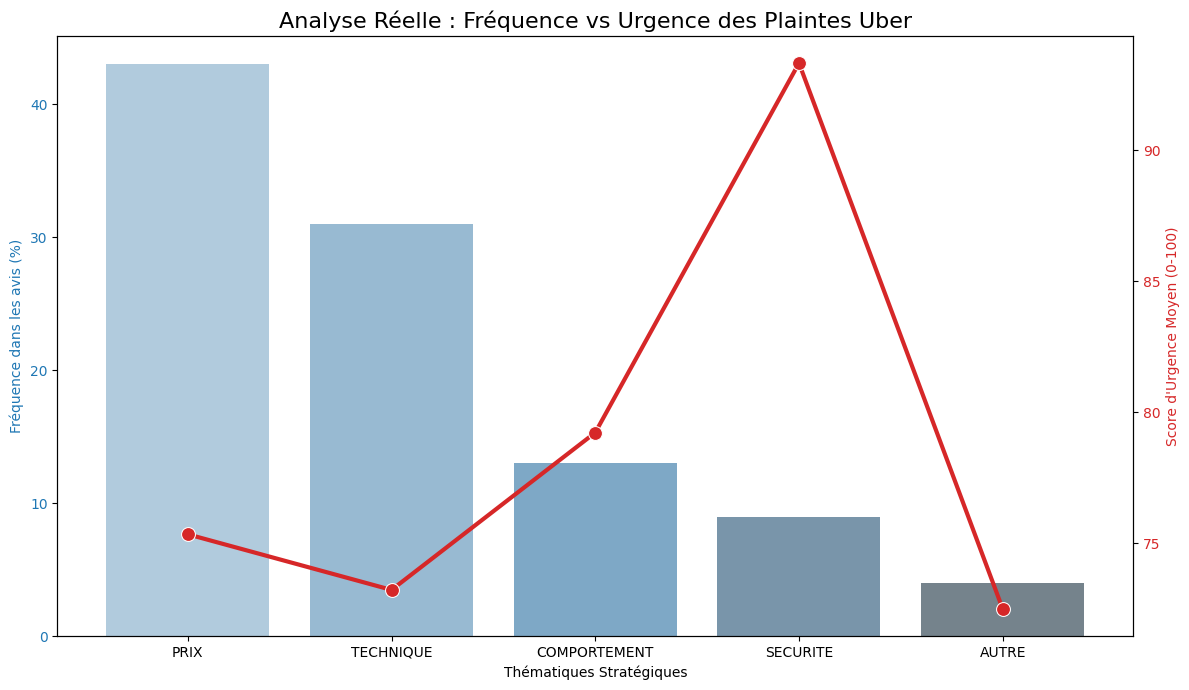

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns


# On fusionne tout ça dans un tableau propre
stats_df = pd.DataFrame({
    'Frequence_PCT': frequences_reelles,
    'Urgence_Score': urgence_reelle
}).reset_index()
stats_df.rename(columns={'index': 'Categorie', 'categorie': 'Categorie'}, inplace=True)
stats_df = stats_df.sort_values(by='Frequence_PCT', ascending=False) # Trier par fréquence

print("📊 Vraies données calculées :")
print(stats_df)

# 2. LE GRAPHIQUE DYNAMIQUE
fig, ax1 = plt.subplots(figsize=(12, 7))

# Axe 1 : Les vraies fréquences (Barres)
ax1.set_title('Analyse Réelle : Fréquence vs Urgence des Plaintes Uber', fontsize=16)
ax1.set_xlabel('Thématiques Stratégiques')
ax1.set_ylabel('Fréquence dans les avis (%)', color='tab:blue')
sns.barplot(data=stats_df, x='Categorie', y='Frequence_PCT', ax=ax1, palette='Blues_d', alpha=0.7)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Axe 2 : Les vrais scores d'urgence (Ligne)
ax2 = ax1.twinx()
ax2.set_ylabel('Score d\'Urgence Moyen (0-100)', color='tab:red')
sns.lineplot(data=stats_df, x='Categorie', y='Urgence_Score', ax=ax2, color='tab:red', marker='o', linewidth=3, markersize=10)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.tight_layout()
plt.show()

### Analyse des Insights IA (Données Réelles)

Ce graphique à double axe croise la **fréquence** des plaintes (barres bleues) avec leur **score de gravité moyen** évalué par le LLM (ligne rouge). Il permet de distinguer les problèmes de volume des problèmes critiques.

**Constats Data-Driven :**
* **Le Volume (Friction quotidienne) :** Les thématiques **PRIX** (~43%) et **TECHNIQUE** (~31%) dominent largement. Ce sont les irritants majeurs qui dégradent la note moyenne de l'application sur les stores.
* **L'Urgence (Risque critique) :** La **SÉCURITÉ** ne représente que 10% des avis critiques de notre échantillon. Pourtant, l'IA détecte une sémantique alarmante et lui attribue le score de gravité le plus élevé (90/100). 
* **Le Comportement :** Les incidents liés au comportement (15%) maintiennent un niveau d'urgence élevé (près de 80/100), soulignant l'importance de la relation client lors des trajets.

**Recommandation Exécutive :**
Une stratégie "Data-Informed" à deux vitesses s'impose :
1. **Équipes Produit/Tech :** Déployer des correctifs sur l'application et clarifier la tarification pour endiguer l'hémorragie des avis 1-étoile (gestion du volume).
2. **Direction/Légal :** Isoler et traiter immédiatement les 10% d'avis liés à la sécurité, car ils portent un risque juridique et réputationnel majeur pour la marque (gestion du risque).